# Which segment?

**Week 1, Tuesday. Notebook 3 of 5, round 3.** By the end of this notebook you can write two
functions that return the tree and the shape of any group of orders, run them on any segment and
quarter, and roll a rate up to the company figure without averaging the averages.

> **The client asks.** "One of my members says the app's reorder button has been broken for six
> weeks. Is my tier the one slipping?"
>
> The head of Retail-Plus, Kalpa's paid membership tier

> **And the question behind it.** "Are we losing customers, or are the ones we have buying less?"
>
> Meera Raghavan, CEO, Kalpa Retail

Round 2 found the branch: customers held at 69, orders per customer fell from 1.65 to 1.25 and took
Rs 51,57,895 with it, revenue per order rose 18.0 percent, and the discount branch is worth at most
Rs 12,900. This round asks where inside the company the fall in frequency sits, and it needs the
same numbers for every segment in both quarters.

> **Kavya's review of round 2.** "You wrote the same accumulating loop three times yesterday and
> today. The fourth time, write it once, give it a name, and make it hand back its answer."

**Setup.** The walk-up import finds `c2kit`, the export loads, and a dictionary of dictionaries
holds the orders of each quarter and segment, so `groups["Q1"]["Business"]` is a list of orders.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
groups = {"Q1": {}, "Q2": {}}
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    q, seg = order["quarter"], order["segment"]
    if seg not in groups[q]:
        groups[q][seg] = []
    groups[q][seg].append(order)
    by_quarter[q].append(order)
print(len(SEGMENTS), "segments,", len(ORDERS), "orders grouped by quarter and segment")

4 segments, 200 orders grouped by quarter and segment


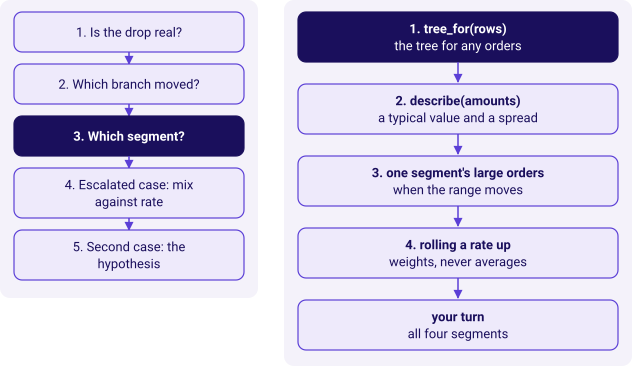

In [2]:
kit.side_by_side(
    kit.ladder(["Is the drop real?", "Which branch moved?", "Which segment?", "Escalated case: mix against rate", "Second case: the hypothesis"], lit=2, show=False),
    kit.vflow(["1. tree_for(rows)\nthe tree for any orders",
               "2. describe(amounts)\na typical value and a spread",
               "3. one segment's large orders\nwhen the range moves",
               "4. rolling a rate up\nweights, never averages",
               "your turn\nall four segments"], lit=0, show=False),
)

## 1. A function returns the tree for any list of orders

The same four numbers are needed for two quarters and four segments, eight groups in all. A
function writes the decision once: `tree_for(rows)` takes any list of orders and returns a
dictionary of the tree's leaves. It returns rather than prints, so the caller can put the answer in
a table, a chart or a check.

**Predict before you run.** What will `tree_for(by_quarter["Q1"])["orders_per_customer"]` give,
rounded? a) 1.65; b) 1.25; c) `None`; d) 1.94.

In [3]:
def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers,
            "revenue_per_order": revenue / orders}

q1 = tree_for(by_quarter["Q1"])
q2 = tree_for(by_quarter["Q2"])
kit.table(["Leaf", "Q1", "Q2"],
          [("revenue", kit.rupees(q1["revenue"]), kit.rupees(q2["revenue"])),
           ("orders", q1["orders"], q2["orders"]),
           ("customers", q1["customers"], q2["customers"]),
           ("orders per customer", f'{q1["orders_per_customer"]:.2f}', f'{q2["orders_per_customer"]:.2f}'),
           ("revenue per order", kit.rupees(round(q1["revenue_per_order"])), kit.rupees(round(q2["revenue_per_order"])))],
          caption="tree_for on the quarter totals")

Leaf,Q1,Q2
revenue,"Rs 2,10,00,000","Rs 1,87,00,000"
orders,114,86
customers,69,69
orders per customer,1.65,1.25
revenue per order,"Rs 1,84,211","Rs 2,17,442"


**What happened.** The answer is a. The function reproduces round 2 exactly: 1.65 in Q1 and 1.25 in
Q2, on 69 customers each. Option c is what a function hands back when it prints its answer and
returns nothing, and the next cell shows that in passing.

In [4]:
def opc_printed(rows):
    t = tree_for(rows)
    print(f'orders per customer: {t["orders_per_customer"]:.2f}')      # prints, returns nothing

result = opc_printed(by_quarter["Q1"])
print("what the caller got back:", result)
kit.check("a function that only prints hands back None", result is None)
kit.check("tree_for reproduces round 2's orders per customer",
          (round(q1["orders_per_customer"], 2), round(q2["orders_per_customer"], 2)) == (1.65, 1.25))
kit.check("tree_for reproduces round 2's revenue", (q1["revenue"], q2["revenue"]) == (21000000, 18700000))
kit.check("tree_for returns all five leaves", len(q1) == 5 and "revenue_per_order" in q1, ", ".join(q1))

orders per customer: 1.65
what the caller got back: None


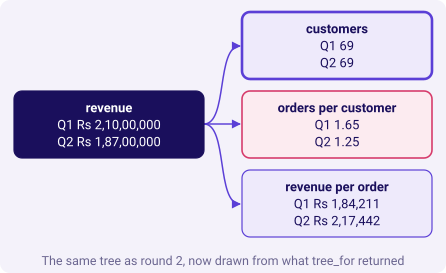

In [5]:
kit.driver_tree({"label": "revenue", "note": f'Q1 {kit.rupees(q1["revenue"])}\nQ2 {kit.rupees(q2["revenue"])}', "kind": "lit", "children": [
    {"label": "customers", "note": f'Q1 {q1["customers"]}\nQ2 {q2["customers"]}', "kind": "known"},
    {"label": "orders per customer", "note": f'Q1 {q1["orders_per_customer"]:.2f}\nQ2 {q2["orders_per_customer"]:.2f}', "kind": "bad"},
    {"label": "revenue per order", "note": f'Q1 {kit.rupees(round(q1["revenue_per_order"]))}\nQ2 {kit.rupees(round(q2["revenue_per_order"]))}'}]},
    title="The same tree as round 2, now drawn from what tree_for returned", width_per=190)

## 2. Retail-Core: frequency slipped a little, and the typical order fell

A segment gets a typical value and a spread, and `describe(amounts)` returns both: the median, the
smallest and largest order, and the range between them. The median is Monday's by-hand version,
with the odd and the even case.

**Predict before you run.** Retail-Core's orders per customer, Q1 against Q2: a) it fell by about
a quarter, like the company; b) it rose; c) it fell by about 5 percent; d) it did not move.

In [6]:
def describe(amounts):
    """A group's typical value and spread: median, min, max and range."""
    ordered = sorted(amounts)
    n = len(ordered)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2
    return {"median": median, "min": ordered[0], "max": ordered[-1], "range": ordered[-1] - ordered[0]}

core = {}
core_amounts = {}
for q in ("Q1", "Q2"):
    core[q] = tree_for(groups[q]["Retail-Core"])
    core_amounts[q] = []
    for order in groups[q]["Retail-Core"]:
        core_amounts[q].append(order["amount"])
core_shape = {"Q1": describe(core_amounts["Q1"]), "Q2": describe(core_amounts["Q2"])}
core_change = (core["Q2"]["orders_per_customer"] / core["Q1"]["orders_per_customer"] - 1) * 100

rows = []
for q in ("Q1", "Q2"):
    rows.append((q, core[q]["orders"], core[q]["customers"], f'{core[q]["orders_per_customer"]:.2f}', kit.rupees(core[q]["revenue"]),
                 kit.rupees(round(core_shape[q]["median"])), kit.rupees(core_shape[q]["min"]),
                 kit.rupees(core_shape[q]["max"]), kit.rupees(core_shape[q]["range"])))
kit.table(["Retail-Core", "Orders", "Customers", "Orders per customer", "Revenue", "Median", "Min", "Max", "Range"], rows,
          caption=f"Retail-Core orders per customer moved {core_change:.1f} percent")

Retail-Core,Orders,Customers,Orders per customer,Revenue,Median,Min,Max,Range
Q1,38,34,1.12,"Rs 80,460","Rs 2,325",Rs 860,"Rs 3,000","Rs 2,140"
Q2,36,34,1.06,"Rs 72,510","Rs 2,080",Rs 890,"Rs 2,950","Rs 2,060"


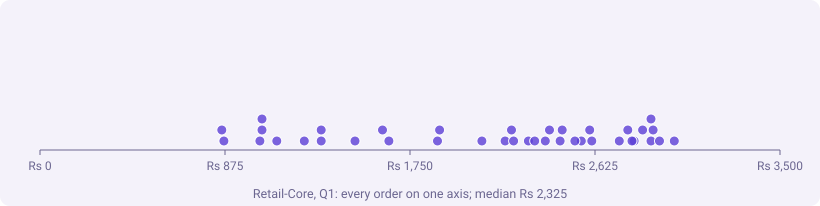

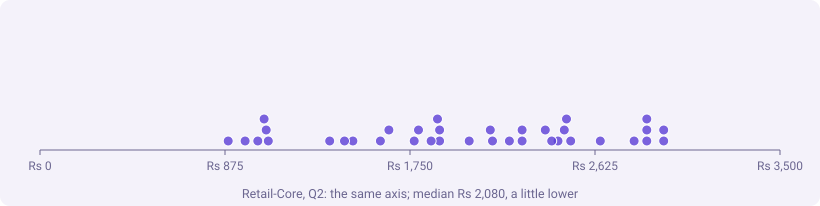

In [7]:
kit.strip(core_amounts["Q1"], lo=0, hi=3500,
          title=f'Retail-Core, Q1: every order on one axis; median {kit.rupees(core_shape["Q1"]["median"])}')
kit.strip(core_amounts["Q2"], lo=0, hi=3500,
          title=f'Retail-Core, Q2: the same axis; median {kit.rupees(core_shape["Q2"]["median"])}, a little lower')

**What happened.** The answer is c. The same 34 Retail-Core customers placed 36 orders against 38,
so orders per customer moved from 1.12 to 1.06, down 5.3 percent. The typical order fell from
Rs 2,325 to Rs 2,080, and the spread held at about two thousand rupees. Retail-Core slipped a
little, which is far short of the company's 24.6 percent.

In [8]:
kit.check("Retail-Core customers held at 34", core["Q1"]["customers"] == core["Q2"]["customers"] == 34)
kit.check("Retail-Core orders per customer fell 5.3 percent", round(core_change, 1) == -5.3, f"{core_change:.2f}")
kit.check("the median of an even count averages the two middles", core_shape["Q1"]["median"] == 2325,
          f'{len(core_amounts["Q1"])} orders, median {core_shape["Q1"]["median"]}')

## 3. Business: the median barely moves while the range nearly doubles

**Predict before you run.** Business revenue fell from Rs 2,07,71,180 to Rs 1,85,41,460. What does
`describe` show about the typical Business order? a) the median fell by about a tenth, like
revenue; b) the median barely moved and the largest order grew a lot; c) every order got smaller;
d) the median rose sharply.

Business,Orders,Customers,Orders per customer,Revenue,Median,Min,Max,Range
Q1,20,11,1.82,"Rs 2,07,71,180","Rs 9,83,780","Rs 2,03,060","Rs 17,84,000","Rs 15,80,940"
Q2,17,11,1.55,"Rs 1,85,41,460","Rs 9,52,000","Rs 2,17,000","Rs 29,45,460","Rs 27,28,460"


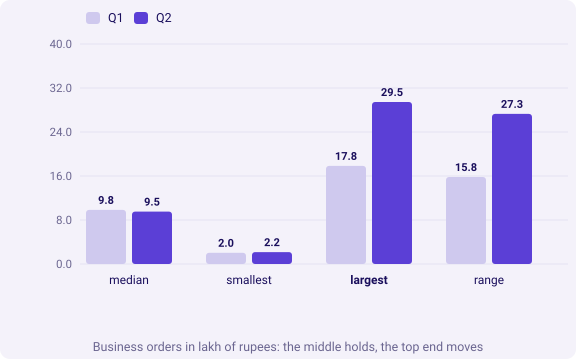

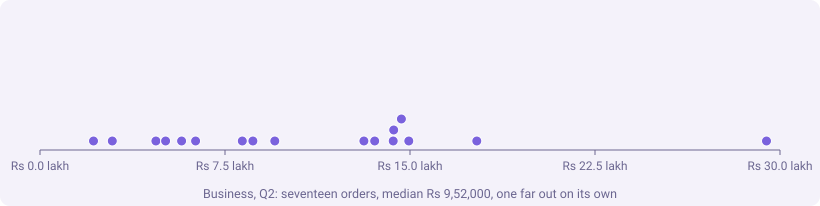

In [9]:
biz = {}
biz_amounts = {}
for q in ("Q1", "Q2"):
    biz[q] = tree_for(groups[q]["Business"])
    biz_amounts[q] = []
    for order in groups[q]["Business"]:
        biz_amounts[q].append(order["amount"])
biz_shape = {"Q1": describe(biz_amounts["Q1"]), "Q2": describe(biz_amounts["Q2"])}
biz_change = (biz["Q2"]["orders_per_customer"] / biz["Q1"]["orders_per_customer"] - 1) * 100

rows = []
for q in ("Q1", "Q2"):
    rows.append((q, biz[q]["orders"], biz[q]["customers"], f'{biz[q]["orders_per_customer"]:.2f}', kit.rupees(biz[q]["revenue"]),
                 kit.rupees(round(biz_shape[q]["median"])), kit.rupees(biz_shape[q]["min"]),
                 kit.rupees(biz_shape[q]["max"]), kit.rupees(biz_shape[q]["range"])))
kit.table(["Business", "Orders", "Customers", "Orders per customer", "Revenue", "Median", "Min", "Max", "Range"], rows,
          caption=f"Business orders per customer moved {biz_change:.1f} percent")
kit.columns(["median", "smallest", "largest", "range"],
            [("Q1", [biz_shape["Q1"]["median"], biz_shape["Q1"]["min"], biz_shape["Q1"]["max"], biz_shape["Q1"]["range"]]),
             ("Q2", [biz_shape["Q2"]["median"], biz_shape["Q2"]["min"], biz_shape["Q2"]["max"], biz_shape["Q2"]["range"]])],
            fmt=lambda v: f"{v / 1e5:.1f}", lit=[2],
            title="Business orders in lakh of rupees: the middle holds, the top end moves")
kit.strip(biz_amounts["Q2"], lo=0, hi=3000000, fmt=lambda v: f"Rs {v / 1e5:.1f} lakh",
          title=f'Business, Q2: seventeen orders, median {kit.rupees(biz_shape["Q2"]["median"])}, one far out on its own')

**What happened.** The answer is b. The median Business order moved from Rs 9,83,780 to
Rs 9,52,000, while the largest order grew from Rs 17,84,000 to Rs 29,45,460 and the range nearly
doubled, from Rs 15,80,940 to Rs 27,28,460. One large order sets the range. The eleven Business
customers placed 17 orders against 20, so orders per customer moved from 1.82 to 1.55, down
15.0 percent, on three orders.

> **Kavya's review.** "Two functions, eight groups, no copied loops: that is the point of today.
> Look at what you can say now. Retail-Core slipped 5.3 percent and Business 15.0 percent, and
> neither of them is 24.6. Before you guess where the rest sits, roll the segments back up and make
> sure you get 1.65 and 1.25 again."

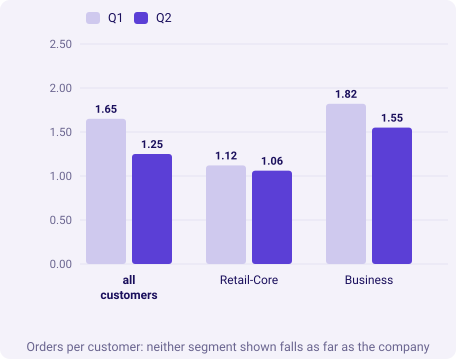

In [10]:
kit.check("Business customers held at 11", biz["Q1"]["customers"] == biz["Q2"]["customers"] == 11)
kit.check("Business orders per customer fell 15.0 percent", round(biz_change, 1) == -15.0, f"{biz_change:.2f}")
kit.check("the Business range nearly doubled while the median moved under 4 percent",
          biz_shape["Q2"]["range"] / biz_shape["Q1"]["range"] > 1.7
          and abs(biz_shape["Q2"]["median"] / biz_shape["Q1"]["median"] - 1) < 0.04,
          f'range x{biz_shape["Q2"]["range"] / biz_shape["Q1"]["range"]:.2f}')
kit.columns(["all customers", "Retail-Core", "Business"],
            [("Q1", [round(q1["orders_per_customer"], 2), round(core["Q1"]["orders_per_customer"], 2), round(biz["Q1"]["orders_per_customer"], 2)]),
             ("Q2", [round(q2["orders_per_customer"], 2), round(core["Q2"]["orders_per_customer"], 2), round(biz["Q2"]["orders_per_customer"], 2)])],
            fmt=lambda v: f"{v:.2f}", lit=[0], title="Orders per customer: neither segment shown falls as far as the company")

## 4. Rolling the segments up: the average of the averages says 6.0 percent

With `tree_for` in hand, the company figure looks one line away: run it on all four segments and
average their orders per customer.

**Predict before you run.** Averaged over the four segments, how far does orders per customer
fall? a) 24.6 percent, the same as round 2; b) much less than round 2; c) more than round 2; d) it
rises.

**The plausible wrong answer.** A hurried analyst averages the four segment rates in each quarter.

In [11]:
averaged = {}
for q in ("Q1", "Q2"):
    total = 0
    for seg in SEGMENTS:
        total += tree_for(groups[q][seg])["orders_per_customer"]
    averaged[q] = total / len(SEGMENTS)
averaged_change = (averaged["Q2"] / averaged["Q1"] - 1) * 100

kit.stats([(f'{averaged["Q1"]:.2f}', "Q1, average of 4 segments", "each segment counted once"),
           (f'{averaged["Q2"]:.2f}', "Q2, average of 4 segments", "each segment counted once"),
           (f"{averaged_change:.1f}%", "the hurried change", "so frequency is not the branch?")])

**Why it is wrong.** The answer to the prediction is b, and it is the wrong conclusion. Averaging
the averages gives every segment one vote, so a segment of 2 customers counts as much as one of 34.
"Frequency fell only 6.0 percent, so it is not the branch, and Marketing may be right" would send
Meera back to the acquisition budget on a number that describes no customer. The check: a roll-up
of the segments must reproduce the company figure from round 2, 1.65 and 1.25, and this one does
not.

The mechanism on **invented** numbers: 30 customers who order 1.1 times each, and 2 customers who
order 3.5 times each.

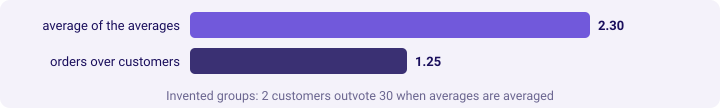

In [12]:
# invented: two groups of customers, not Kalpa's
small_group = {"customers": 2, "orders_per_customer": 3.5}
large_group = {"customers": 30, "orders_per_customer": 1.1}
avg_of_avgs = (small_group["orders_per_customer"] + large_group["orders_per_customer"]) / 2
orders_all = small_group["customers"] * small_group["orders_per_customer"] + large_group["customers"] * large_group["orders_per_customer"]
weighted_inv = orders_all / (small_group["customers"] + large_group["customers"])
kit.bars([("average of the averages", round(avg_of_avgs, 2)), ("orders over customers", round(weighted_inv, 2))],
         fmt=lambda v: f"{v:.2f}", lit=[1], title="Invented groups: 2 customers outvote 30 when averages are averaged")
kit.check("on the invented groups the two roll-ups differ by more than 1.0", avg_of_avgs - weighted_inv > 1.0,
          f"{avg_of_avgs:.2f} against {weighted_inv:.2f}")

In [13]:
kit.check("the averaged roll-up misses round 2's Q1 figure", round(averaged["Q1"], 2) != round(q1["orders_per_customer"], 2),
          f'{averaged["Q1"]:.2f} against {q1["orders_per_customer"]:.2f}')
kit.check("the hurried change is minus 6.0 percent", round(averaged_change, 1) == -6.0, f"{averaged_change:.2f}")

**The fix.** Weight by customers: add the orders across segments and divide by the customers
across segments. Count the groups in and the groups out as you do it: four segments go in, and
their customers must add back to the 69 of round 2.

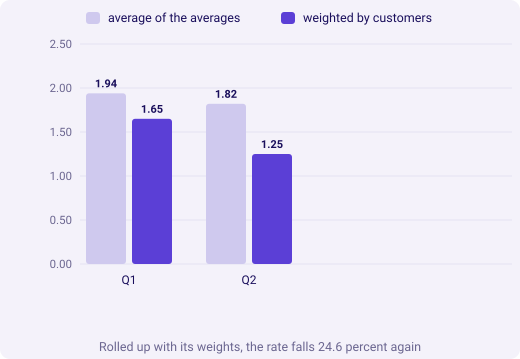

In [14]:
weighted = {}
groups_used = {}
customers_used = {}
for q in ("Q1", "Q2"):
    all_orders = 0
    all_customers = 0
    groups_used[q] = 0
    for seg in SEGMENTS:
        t = tree_for(groups[q][seg])
        all_orders += t["orders"]
        all_customers += t["customers"]
        groups_used[q] += 1
    weighted[q] = all_orders / all_customers
    customers_used[q] = all_customers
weighted_change = (weighted["Q2"] / weighted["Q1"] - 1) * 100

kit.columns(["Q1", "Q2"], [("average of the averages", [round(averaged["Q1"], 2), round(averaged["Q2"], 2)]),
                           ("weighted by customers", [round(weighted["Q1"], 2), round(weighted["Q2"], 2)])],
            fmt=lambda v: f"{v:.2f}", width=520, title="Rolled up with its weights, the rate falls 24.6 percent again")
kit.check("the weighted roll-up reproduces round 2", abs(weighted["Q1"] - q1["orders_per_customer"]) < 1e-12
          and abs(weighted["Q2"] - q2["orders_per_customer"]) < 1e-12, f'{weighted["Q1"]:.2f} and {weighted["Q2"]:.2f}')
kit.check("four groups in, four groups out, in both quarters", groups_used["Q1"] == groups_used["Q2"] == len(SEGMENTS))
kit.check("the segments' customers add back to 69", customers_used["Q1"] == customers_used["Q2"] == 69)

**What changed.** "Frequency fell 6.0 percent, so Marketing may be right" became "orders per
customer fell from 1.65 to 1.25, 24.6 percent, across the same 69 customers", which keeps
frequency as the branch and keeps the acquisition budget shut. Retail-Core and Business account
for part of it, and the weighted roll-up says the rest sits in the segments not yet opened.

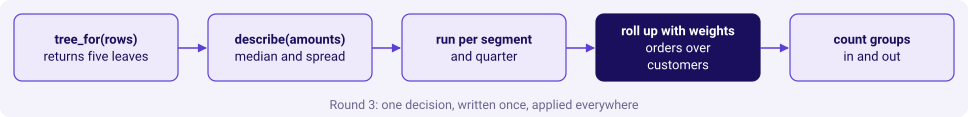

Finding,Number
tree_for on the quarter totals,1.65 to 1.25
Retail-Core orders per customer,-5.3%
Business orders per customer,"-15.0%, on 3 fewer orders"
the average of four segment averages,"1.94 to 1.82, the wrong roll-up"
the weighted roll-up,"1.65 to 1.25, -24.6%"


In [15]:
kit.flow(["tree_for(rows)\nreturns five leaves", "describe(amounts)\nmedian and spread",
          "run per segment\nand quarter", "roll up with weights\norders over customers",
          "count groups\nin and out"], lit=3, title="Round 3: one decision, written once, applied everywhere")
kit.table(["Finding", "Number"],
          [("tree_for on the quarter totals", f'{q1["orders_per_customer"]:.2f} to {q2["orders_per_customer"]:.2f}'),
           ("Retail-Core orders per customer", f"{core_change:.1f}%"),
           ("Business orders per customer", f'{biz_change:.1f}%, on {biz["Q1"]["orders"] - biz["Q2"]["orders"]} fewer orders'),
           ("the average of four segment averages", f'{averaged["Q1"]:.2f} to {averaged["Q2"]:.2f}, the wrong roll-up'),
           ("the weighted roll-up", f'{weighted["Q1"]:.2f} to {weighted["Q2"]:.2f}, {weighted_change:.1f}%')],
          caption="What round 3 established")

**Your turn.** Run the tree for all four segments in both quarters. Type these lines into the empty
cell below and run them:

```python
rows = []
opc_q1, opc_q2 = [], []
for seg in SEGMENTS:
    t1 = tree_for(groups["Q1"][seg])
    t2 = tree_for(groups["Q2"][seg])
    rows.append((seg, t1["customers"], t2["customers"], t1["orders"], t2["orders"],
                 f'{t1["orders_per_customer"]:.2f}', f'{t2["orders_per_customer"]:.2f}'))
    opc_q1.append(round(t1["orders_per_customer"], 2))
    opc_q2.append(round(t2["orders_per_customer"], 2))
kit.table(["Segment", "Customers Q1", "Customers Q2", "Orders Q1", "Orders Q2", "Per customer Q1", "Per customer Q2"], rows)
kit.columns(SEGMENTS, [("Q1", opc_q1), ("Q2", opc_q2)], fmt=lambda v: f"{v:.2f}",
            title="Orders per customer by segment")
```

Then write one sentence for the head of Retail-Plus that answers his question with a number and its
denominator, and one line saying which segment's customers you would open next and why.

### In the interview

**[F] Why does a function that prints instead of returning break a pipeline?** "Because printing
sends the answer to the screen and returns `None` to the caller. The next step, a table, a sum, a
chart or a check, receives `None`, and it either crashes or, worse, carries on: a filter that
drops `None` values quietly removes the groups whose result was only printed. A function should
return its answer every time, in the same type, and leave display to the caller. If some results
need a human look, the function returns a flag beside the value." The interviewer is listening for
`None`, for the silent case, and for the separation of computing from showing.

**[F] You have orders per customer for four segments; why can't you average them for the company
figure?** "Because each segment's rate has its own denominator, and averaging the rates gives
every segment the same weight whatever its size. The company figure is total orders over total
customers, which is the segment rates weighted by their customers. On Kalpa's quarters the
unweighted average said frequency fell 6.0 percent and the weighted figure says 24.6 percent. The
test I run on any roll-up is that it reproduces the company total; if it does not, the roll-up is
wrong." The interviewer is listening for denominators, weights and the reproduce-the-total test.

### Depth: what a range can and cannot say

A range is set by two orders, the smallest and the largest, so one order can double it, as
Business showed. A median is set by the middle of the list, so it barely moves. Between the two, a
spread that ignores the ends, such as the middle half of the sorted values, says how wide the
ordinary orders sit. Try it on Business: sort each quarter's amounts, drop the lowest and highest
quarter of the list, and take the range of what is left. Thursday asks whether differences of this
size are more than noise.

References for the round:

- Corey Schafer, "Python Tutorial for Beginners 8: Functions": https://www.youtube.com/watch?v=9Os0o3wzS_I (verified 29 Sep 2026)
- Python docs, "4. More Control Flow Tools", defining functions and return: https://docs.python.org/3/tutorial/controlflow.html (verified 29 Sep 2026)
- Python docs, statistics module, median: https://docs.python.org/3/library/statistics.html (verified 29 Sep 2026)
- Khan Academy, mean, median and mode review: https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/mean-median-basics/a/mean-median-and-mode-review (verified 29 Sep 2026)
- Khan Academy, summarizing quantitative data: https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data (verified 29 Sep 2026)

In [16]:
kit.check_summary()
print("Next: the escalated case, which asks whether revenue per order rose because of mix or because of rate.")

Next: the escalated case, which asks whether revenue per order rose because of mix or because of rate.
